<a href="https://colab.research.google.com/github/fenix1795/CLIMATOL-ESC/blob/main/Copia_de_mapa_de_spi_ancashipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

instalar paquetes de rasterio para abrir los raster

In [ ]:
!pip install rasterio geopandas matplotlib contextily

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from rasterio.mask import mask

In [ ]:
import geopandas as gpd
import rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

ingresar la capa vectorial en sistema de proyeccion en grados

In [ ]:
ancash = gpd.read_file("/content/drive/MyDrive/ANALISIS VARIABILIDAD CLIMATICA/Ancash_grados.shp")

provincias = gpd.read_file("/content/drive/MyDrive/ANALISIS VARIABILIDAD CLIMATICA/provincias_ancash.shp")

aqui se sube los raster que esatn guardados en un drive y luego se pone los nombres para que salgan en los graficos


In [ ]:
spi_files = [
"/content/drive/MyDrive/GEE1/SPI_Nov_2025.tif",
"/content/drive/MyDrive/GEE1/SPI_Dec_2025.tif",
"/content/drive/MyDrive/GEE1/SPI_Jan_2026.tif",
"/content/drive/MyDrive/GEE1/SPI_Feb_2026_ERA5.tif"

]

titles = [
"SPI Noviembre 2025",
"SPI Diciembre 2025",
"SPI Enero 2026",
"SPI Febrero 2026 ERA 5",
]

Aplicar la clasificación al mapa

In [ ]:
# obtener valores sin NaN
vals = data[~np.isnan(data)]

# calcular cuantiles (7 clases)
bounds = np.quantile(vals, [0,0.14,0.28,0.42,0.56,0.70,0.84,1])

print(bounds)

[-0.42073664 -0.1287885  -0.03410131  0.05396282  0.107079    0.20685355
  0.29814777  0.72242957]


In [ ]:
vals = data[~np.isnan(data)]

# eliminar valores exactamente 0
vals = vals[vals != 0]

bounds = np.quantile(vals,[0,0.14,0.28,0.42,0.56,0.70,0.84,1])

print(bounds)

[-0.42073664 -0.1287885  -0.03410131  0.05396282  0.107079    0.20685355
  0.29814777  0.72242957]


Función de recorte de raster en base a las capa ancash

In [ ]:
import rasterio
from rasterio.mask import mask
from rasterio.plot import plotting_extent

def clip_raster(raster, ancash):

    with rasterio.open(raster) as src:

        ancash_proj = ancash.to_crs(src.crs)

        out_image, out_transform = mask(
            src,
            ancash_proj.geometry,
            crop=True,
            filled=False   # CLAVE
        )

        data = out_image[0].astype("float32")

        # convertir máscara a NaN
        data = np.where(out_image.mask[0], np.nan, data)

        extent = plotting_extent(data, out_transform)

    return data, extent

colores

In [ ]:
colors = [
"#8b0000",
"#d73027",
"#fc8d59",
"#ffffbf",
"#91bfdb",
"#4575b4",
"#313695"
]

cmap = mcolors.ListedColormap(colors)

primer mapa

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

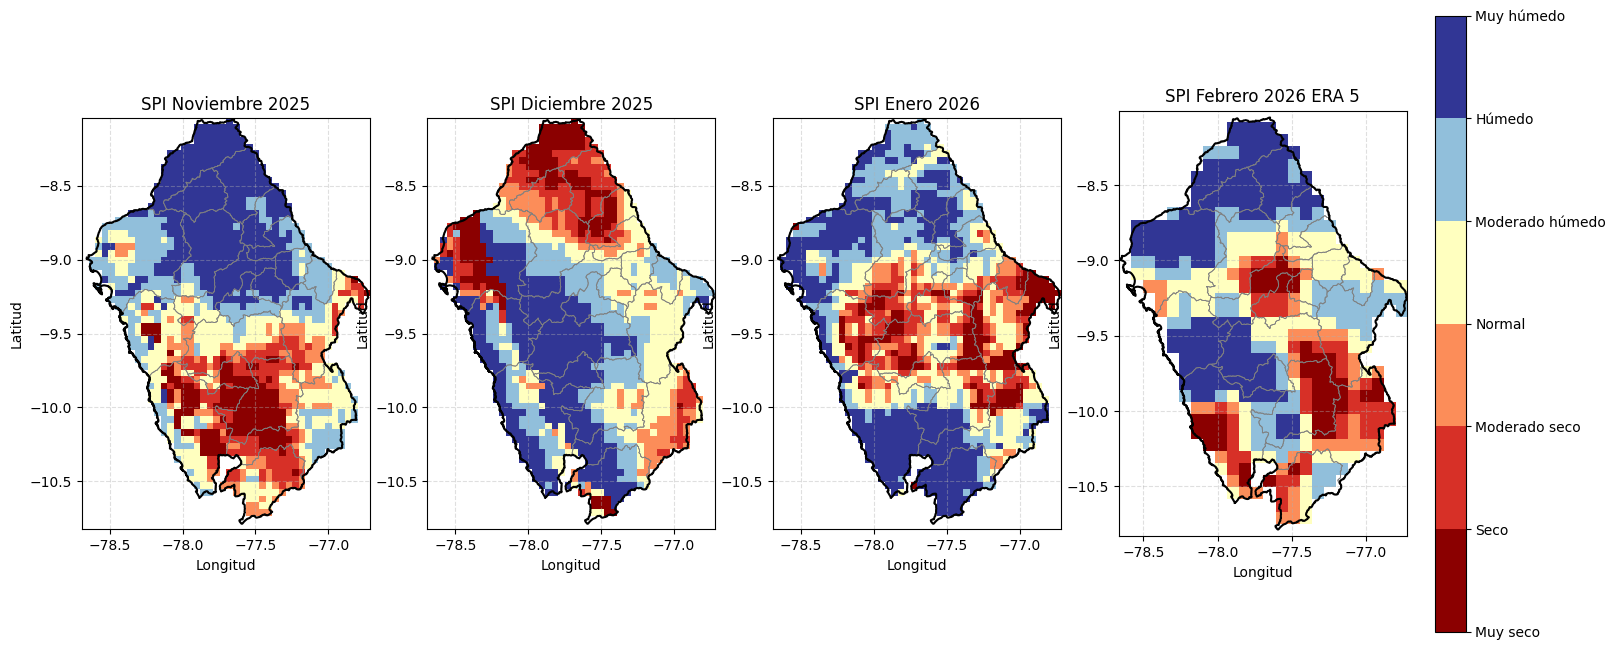

In [ ]:
fig, axes = plt.subplots(1,4, figsize=(18,8))

for i, spi in enumerate(spi_files):

    data, extent = clip_raster(spi, ancash)

    vals = data[~np.isnan(data)]
    vals = vals[vals != 0]

    bounds = np.quantile(vals,[0,0.1,0.2,0.3,0.5,0.7,0.8])

    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    im = axes[i].imshow(
        data,
        cmap=cmap,
        norm=norm,
        extent=extent
    )

    provincias.boundary.plot(ax=axes[i], edgecolor="gray", linewidth=0.6)
    ancash.boundary.plot(ax=axes[i], edgecolor="black", linewidth=1.5)

    axes[i].set_title(titles[i])

    axes[i].set_xlabel("Longitud")
    axes[i].set_ylabel("Latitud")

    axes[i].grid(True, linestyle="--", alpha=0.4)


cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)

cbar.set_ticks(bounds)

cbar.set_ticklabels([
"Muy seco",
"Seco",
"Moderado seco",
"Normal",
"Moderado húmedo",
"Húmedo",
"Muy húmedo"
])

#Segundo ajuste (muy recomendable)

#Antes de imshow agrega:

cmap.set_bad(color='white', alpha=0)

#Esto hace que los NaN sean transparentes.

# Guardar figura automáticamente
plt.savefig("mapas_spi_2026.png", dpi=300, bbox_inches="tight")

# MUY IMPORTANTE PARA QUE SALGA AUTOMATICAMENTE LA IMAGEN A LA PC
from google.colab import files
files.download("mapas_spi_2026.png")

plt.show()


segundo estilo de mapa

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

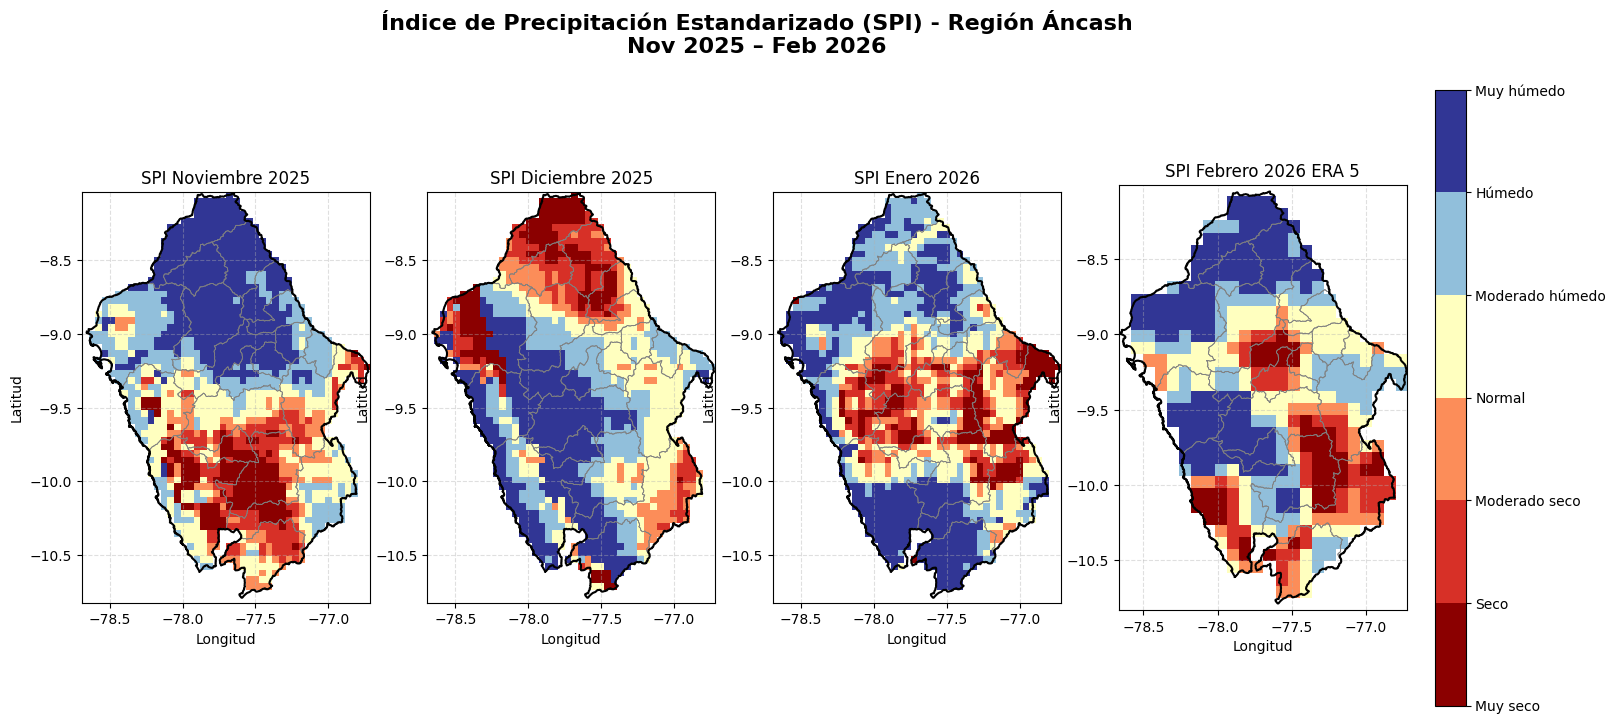

In [ ]:
fig, axes = plt.subplots(1,4, figsize=(18,8))

for i, spi in enumerate(spi_files):

    data, extent = clip_raster(spi, ancash)

    vals = data[~np.isnan(data)]
    vals = vals[vals != 0]

    bounds = np.quantile(vals,[0,0.1,0.2,0.3,0.5,0.7,0.8])

    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    im = axes[i].imshow(
        data,
        cmap=cmap,
        norm=norm,
        extent=extent
    )

    provincias.boundary.plot(ax=axes[i], edgecolor="gray", linewidth=0.6)
    ancash.boundary.plot(ax=axes[i], edgecolor="black", linewidth=1.5)

    axes[i].set_title(titles[i])

    axes[i].set_xlabel("Longitud")
    axes[i].set_ylabel("Latitud")

    axes[i].grid(True, linestyle="--", alpha=0.4)


cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)

cbar.set_ticks(bounds)

cbar.set_ticklabels([
"Muy seco",
"Seco",
"Moderado seco",
"Normal",
"Moderado húmedo",
"Húmedo",
"Muy húmedo"
])


# Título general del mapa
fig.suptitle(
"Índice de Precipitación Estandarizado (SPI) - Región Áncash\nNov 2025 – Feb 2026",
fontsize=16,
fontweight="bold"
)

# transparencia para NaN
cmap.set_bad(color='white', alpha=0)


# Guardar figura
plt.savefig("mapas_spi_2026.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("mapas_spi_2026.png")

plt.show()


estilo final de mapa con flecha y escala

/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/pytho

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

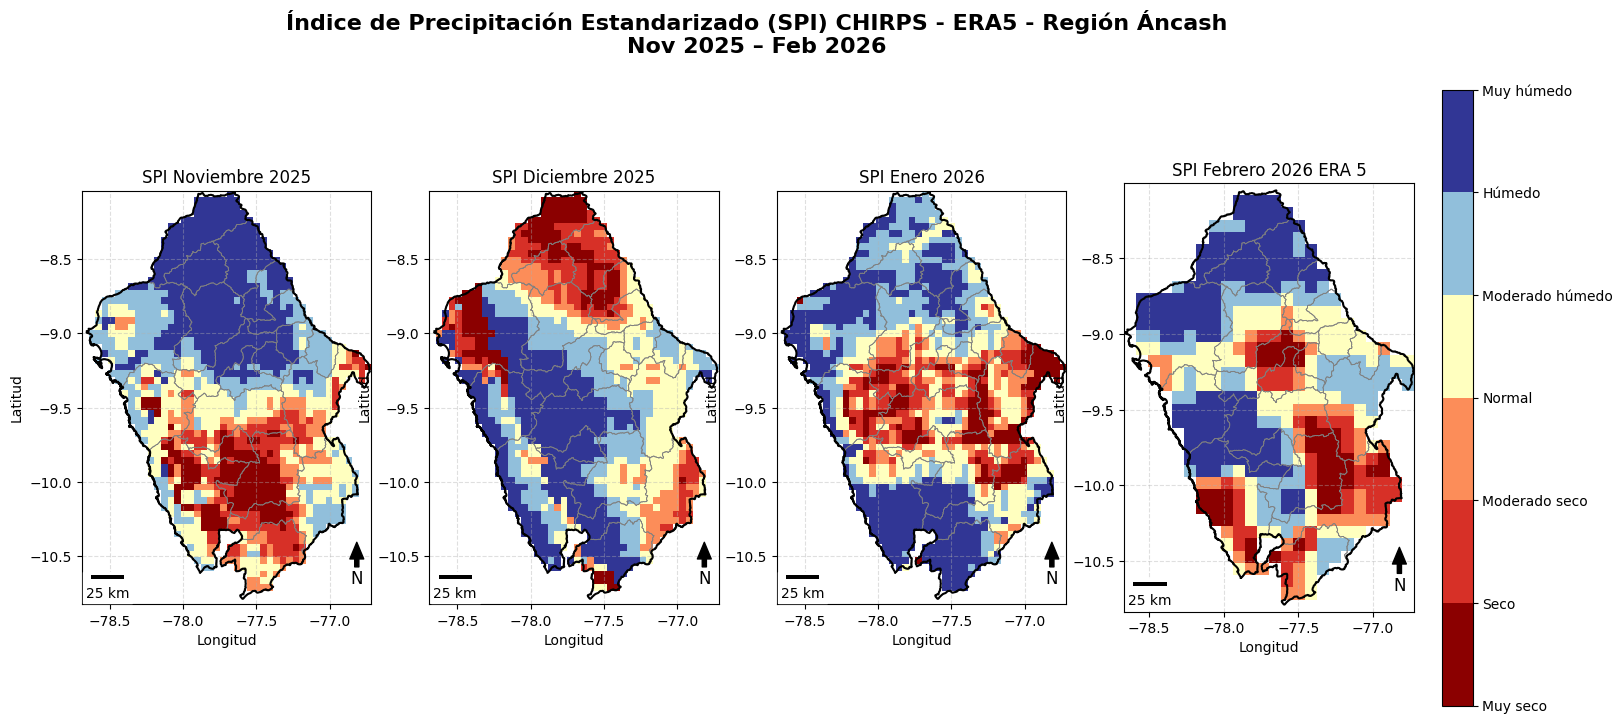

In [ ]:
fig, axes = plt.subplots(1,4, figsize=(18,8))

for i, spi in enumerate(spi_files):

    data, extent = clip_raster(spi, ancash)

    vals = data[~np.isnan(data)]
    vals = vals[vals != 0]

    bounds = np.quantile(vals,[0,0.1,0.2,0.3,0.5,0.7,0.8])

    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    im = axes[i].imshow(
        data,
        cmap=cmap,
        norm=norm,
        extent=extent
    )

    provincias.boundary.plot(ax=axes[i], edgecolor="gray", linewidth=0.6)
    ancash.boundary.plot(ax=axes[i], edgecolor="black", linewidth=1.5)

    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Longitud")
    axes[i].set_ylabel("Latitud")

    axes[i].grid(True, linestyle="--", alpha=0.4)

    # flecha norte
    axes[i].annotate(
        'N',
        xy=(0.95,0.15),
        xytext=(0.95,0.05),
        arrowprops=dict(facecolor='black', width=3, headwidth=10),
        ha='center',
        fontsize=12,
        xycoords=axes[i].transAxes
    )

    # escala
    scalebar = ScaleBar(111000, location='lower left')
    axes[i].add_artist(scalebar)


# barra de color
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)

cbar.set_ticks(bounds)

cbar.set_ticklabels([
"Muy seco",
"Seco",
"Moderado seco",
"Normal",
"Moderado húmedo",
"Húmedo",
"Muy húmedo"
])

# Título general
fig.suptitle(
"Índice de Precipitación Estandarizado (SPI) CHIRPS - ERA5 - Región Áncash\nNov 2025 – Feb 2026",
fontsize=16,
fontweight="bold"
)

# transparencia para NaN
cmap.set_bad(color='white', alpha=0)

# Guardar figura
plt.savefig("mapas_spi_2026.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("mapas_spi_2026.png")

plt.show()

codigo para mapa de anomalias

In [ ]:
!pip install matplotlib-scalebar

ingreso de rasters de anomalía y grafico de anomalias de precipitacion 1

In [ ]:
anom_files = [

"/content/drive/MyDrive/GEE1/Anom_Nov_2025.tif",
"/content/drive/MyDrive/GEE1/Anom_Dec_2025.tif",
"/content/drive/MyDrive/GEE1/Anom_Jan_2026.tif",
 "/content/drive/MyDrive/GEE1/Anom_Feb_2026_ERA5.tif"
]

titles = [

"Nov 2025",
"Dic 2025",
"Ene 2026",
"Feb 2026 Era 5"
]

In [ ]:
#Límites de clasificación (anomalía)
bounds = [-100, -40, -20, -10, 10, 20, 40, 100]

In [ ]:
#Colores recomendados
colors = [
"#8b0000",
"#d73027",
"#fc8d59",
"#ffffbf",
"#91bfdb",
"#4575b4",
"#313695"
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

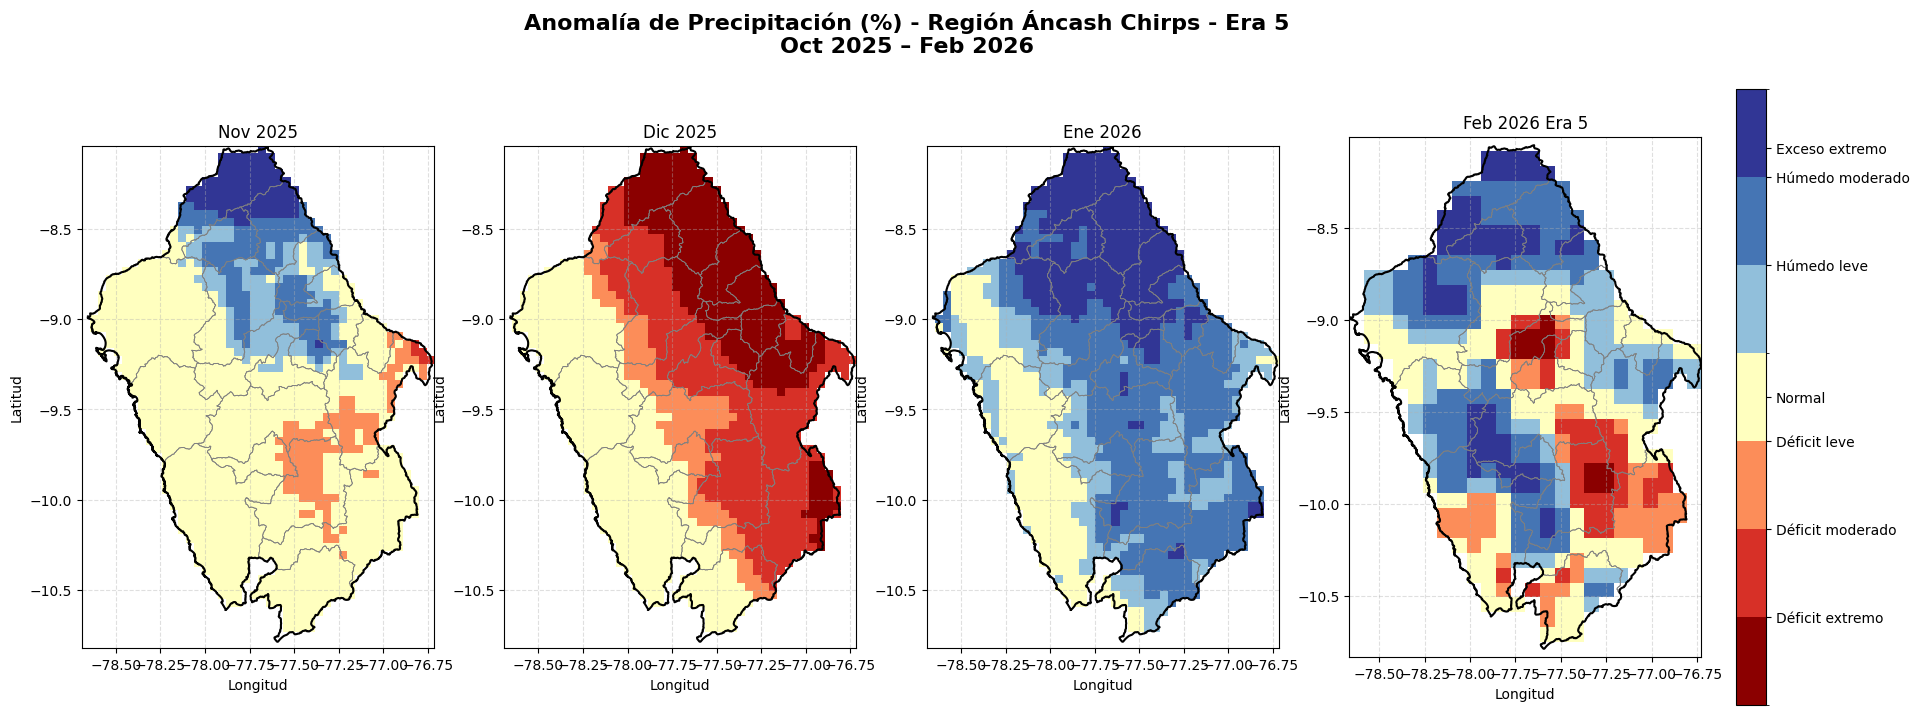

In [ ]:
#Código del mapa
fig, axes = plt.subplots(1,4, figsize=(22,8))

for i, raster in enumerate(anom_files):

    data, extent = clip_raster(raster, ancash)

    im = axes[i].imshow(
        data,
        cmap=cmap,
        norm=norm,
        extent=extent
    )

    provincias.boundary.plot(ax=axes[i], edgecolor="gray", linewidth=0.6)
    ancash.boundary.plot(ax=axes[i], edgecolor="black", linewidth=1.5)

    axes[i].set_title(titles[i], fontsize=12)

    axes[i].set_xlabel("Longitud")
    axes[i].set_ylabel("Latitud")

    axes[i].grid(True, linestyle="--", alpha=0.4)


cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)

cbar.set_ticks([-40,-20,-10,0,20,40,60])

cbar.set_ticklabels([
"Déficit extremo",
"Déficit moderado",
"Déficit leve",
"Normal",
"Húmedo leve",
"Húmedo moderado",
"Exceso extremo"
])


fig.suptitle(
"Anomalía de Precipitación (%) - Región Áncash Chirps - Era 5\nOct 2025 – Feb 2026",
fontsize=16,
fontweight="bold"
)

cmap.set_bad(color='white', alpha=0)

plt.savefig("mapa_anomalias_precipitacion.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("mapa_anomalias_precipitacion.png")

plt.show()

grafico de anomalias de precipitacion 2

In [ ]:
import rasterio
import numpy as np

raster = "/content/drive/MyDrive/GEE1/Anom_Dec_2025.tif"

with rasterio.open(raster) as src:

    data = src.read(1).astype("float32")

    nodata = src.nodata
    data[data == nodata] = np.nan

print("Min:", np.nanmin(data))
print("Max:", np.nanmax(data))
print("Media:", np.nanmean(data))

Min: -117.909546
Max: 34.92767
Media: -33.583813


In [ ]:
colors = [
"#8b0000",   # déficit extremo
"#d73027",   # déficit moderado
"#fc8d59",   # déficit leve
"#ffffbf",   # normal
"#91bfdb",   # húmedo leve
"#4575b4",   # húmedo moderado
"#313695"    # exceso extremo
]

cmap = mcolors.ListedColormap(colors)

In [ ]:
bounds = [-100, -4, -2, 1, 2, 4, 100]

norm = mcolors.BoundaryNorm(bounds, cmap.N)

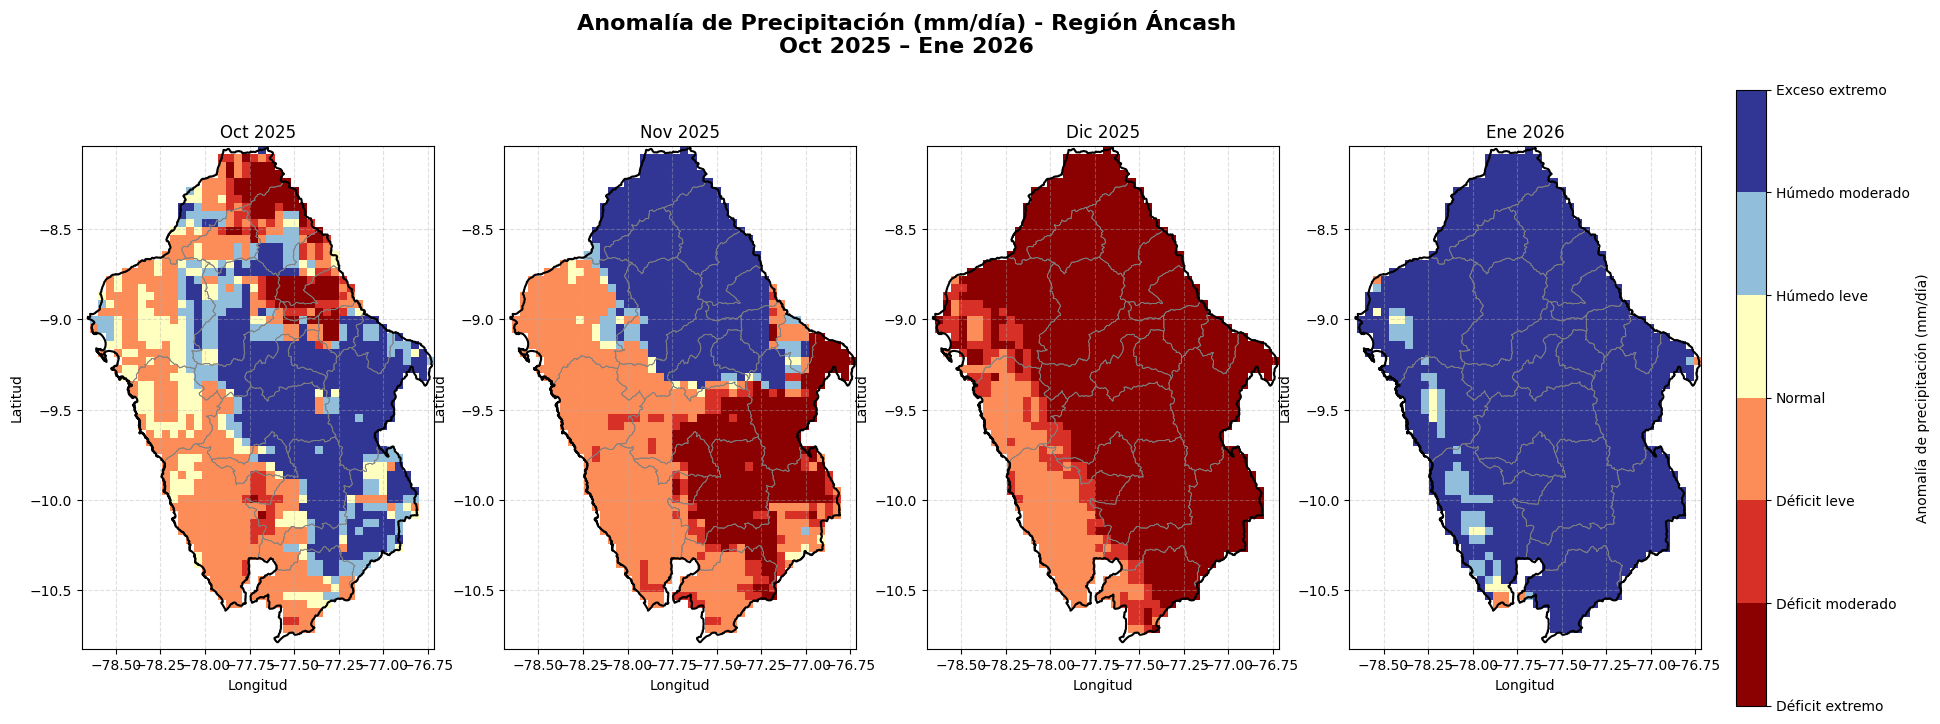

In [ ]:
fig, axes = plt.subplots(1,4, figsize=(22,8))

for i, raster in enumerate(anom_files):

    data, extent = clip_raster(raster, ancash)

    im = axes[i].imshow(
        data,
        cmap=cmap,
        norm=norm,
        extent=extent
    )

    provincias.boundary.plot(ax=axes[i], edgecolor="gray", linewidth=0.6)
    ancash.boundary.plot(ax=axes[i], edgecolor="black", linewidth=1.5)

    axes[i].set_title(titles[i], fontsize=12)

    axes[i].set_xlabel("Longitud")
    axes[i].set_ylabel("Latitud")

    axes[i].grid(True, linestyle="--", alpha=0.4)


cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)

cbar.set_ticks([-100, -4, -2, 1, 2, 4, 100])

cbar.set_ticklabels([
"Déficit extremo",
"Déficit moderado",
"Déficit leve",
"Normal",
"Húmedo leve",
"Húmedo moderado",
"Exceso extremo"
])

cbar.set_label("Anomalía de precipitación (mm/día)")


fig.suptitle(
"Anomalía de Precipitación (mm/día) - Región Áncash\nOct 2025 – Ene 2026",
fontsize=16,
fontweight="bold"
)

cmap.set_bad(color='white', alpha=0)

plt.savefig("mapa_anomalias_mm_dia.png", dpi=300, bbox_inches="tight")

plt.show()